# Quantum-Inspired Kolmogorov-Arnold Networks (QKAN)

**What you'll learn:**
* Why KAN-style edge activations are a candidate replacement for parameter-heavy MLP blocks
* How QKAN embeds single-qubit quantum circuits (DARUANs) as learnable activation functions
* How to train QKAN on function-fitting tasks and use layer extension for deeper circuits
* How **Hybrid QKAN (HQKAN)** scales the same primitive to CNN heads and GPT-2-scale transformer blocks
* How the **`cutn`** (**cuTensorNet** in cuQuantum) solver path represents QKAN circuits as tensor-network contractions
* How QKAN-to-KAN transfer illustrates the optimization-landscape findings from the paper

> **Where you are: Afternoon Block, Notebook 03 — Quantum-Inspired Architectures.**
> After the fast-weight programming ideas in `02_qfwp.ipynb`, this notebook turns to the second model family of the afternoon. Part 1 introduces **QKAN** — a tensor-network reformulation of Kolmogorov–Arnold Networks delivering parameter-efficient LLM building blocks with cuQuantum acceleration.

## Notebook Topic Map

This notebook follows the afternoon QKAN thread in three parts, moving from one learnable quantum-inspired activation edge to the HQKAN block pattern used for larger models.

| Block topic | Notebook path | Hands-on result |
|:---|:---|:---|
| Quantum-inspired architectures for LLMs | **Part 1: From KAN to QKAN** | Learn the DARUAN edge activation, run function fitting, and apply layer extension |
| Parameter-efficient HQKAN scaling | **Part 2: Scaling to LLMs with NVIDIA** | Use a QKAN core in an MNIST proxy and a GPT-2-scale transformer block |
| NVIDIA acceleration path | **Part 2: `cutn` solver demo** | Run the cuTensorNet-assisted QKAN solver path and compare GPT-2 block throughput against the MLP baseline |
| Published results and takeaways | **Part 3: Transfer and Takeaways** | Run the QKAN-to-KAN transfer experiment and connect it to the paper result |

MNIST is included as a runnable proxy for the same compression pattern used later in the GPT-2-scale block.


## Setup

Use the repository virtual environment as the notebook kernel: **QCE26 Tutorials (venv)**. The kernel points to:

```text
/home/jc/git/QCE26_tutorials-scalable-qml/venv/bin/python
```

The base `qkan` install includes the PyTorch reference solver. The `cutn` solver demo uses the tensor-network backend; install the `qkan[cutn]` extra when you want the cuQuantum/cuTensorNet path available. If cuQuantum is not installed, the same `cutn` code path can still build the tensor network and execute with the local fallback, but the timing should be read as a functional fallback rather than cuTensorNet acceleration.


In [1]:
# In a terminal from the repository root, install/refresh the package in the venv if needed:
# ./venv/bin/python -m pip install 'qkan[cutn]' cuquantum-python-cu13 -q


In [2]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm

from qkan import QKAN, KAN, create_dataset

# Full tutorial settings.
FIT_TRAIN_NUM = 1000
FIT_TEST_NUM = 1000
FIT_STEPS = 100

LAYER_TRAIN_NUM = 1000
LAYER_TEST_NUM = 1000
LAYER_INITIAL_STEPS = 100
LAYER_EXT_REPS = [5, 10, 15, 20]
LAYER_EXT_STEPS = 100
LAYER_DIRECT_STEPS = 500

MNIST_BATCH_SIZE = 1000
MNIST_EPOCHS = 20
HQKAN_COMPRESSED_DIM = 16


TRANSFER_TRAIN_NUM = 10_000
TRANSFER_TEST_NUM = 1_000
TRANSFER_QKAN_STEPS = 500
TRANSFER_TRANSFER_STEPS = 1_000
TRANSFER_SCRATCH_STEPS = 1_500
TRANSFER_BATCH_SIZE = None

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Python: {sys.executable}")
print(f"Using device: {device}")
print("Full tutorial settings enabled.")

if "QCE26_tutorials-scalable-qml/venv" not in sys.executable:
    print("Tip: select the Jupyter kernel named 'QCE26 Tutorials (venv)' for the tested cutn setup.")


Python: /home/jc/git/QCE26_tutorials-scalable-qml/venv/bin/python
Using device: cuda
Full tutorial settings enabled.


---
## Part 1: From KAN to QKAN

This part matches the deck's **From KAN to QKAN** topic: start with KAN edge functions, replace spline activations with quantum variational activation functions, then train the resulting QKAN primitive. The important bridge to the LLM topic is that every later HQKAN block reuses this same edge-level activation.

### 1.1 Kolmogorov-Arnold Networks (KAN)

The **Kolmogorov-Arnold representation theorem** states that any multivariate continuous function can be written as a superposition of univariate functions and addition:

$$f(x_1, \ldots, x_n) = \sum_{q=0}^{2n} \Phi_q\!\left(\sum_{p=1}^{n} \phi_{q,p}(x_p)\right)$$

**KAN** (Liu et al., 2024) places *learnable activation functions on edges* rather than fixed activations on nodes. Each layer computes:

$$\mathbf{x}_{l+1,j} = \sum_{i=1}^{n_l} \phi_{l,j,i}(x_{l,i})$$

where $\phi_{l,j,i}$ is a **learnable univariate function** (typically a B-spline). This gives KAN strong approximation power and interpretability, but spline-based activations require $O(G)$ parameters per edge (where $G$ is the grid size).

### 1.2 Quantum Variational Activation Functions (QVAF)

**Key idea:** Replace splines with *single-qubit quantum circuits* as activation functions.

A QVAF is defined as:

$$\phi_\theta(x) = \langle 0 | U(x;\theta)^\dagger \, M \, U(x;\theta) | 0 \rangle$$

where:
- $x \in \mathbb{R}$ is the scalar input (encoded as a rotation angle)
- $U(x;\theta)$ is a parameterized single-qubit unitary (the quantum circuit)
- $M$ is a Hermitian observable ($\|M\| \leq 1$), typically $\sigma_z$
- $\theta$ are the trainable variational parameters

The output is bounded in $[-1, 1]$ and smooth, making it a natural nonlinear activation function.

### 1.3 DARUAN: DatA Re-Uploading ActivatioN

The specific quantum circuit used is called **DARUAN**. It alternates trainable rotations with data-encoding rotations:

$$U(x;\theta) = W^{(r+1)} \prod_{\ell=1}^{r} \left[ S(w_\ell x + b_\ell) \cdot W^{(\ell)} \right]$$

where:
- $W^{(\ell)} = R_Z(\theta_0^{(\ell)}) R_Y(\theta_1^{(\ell)})$ are trainable rotations (variational parameters)
- $S(w_\ell x + b_\ell) = R_Z(w_\ell x + b_\ell)$ encodes the input data with trainable pre-processing weights
- $r$ is the number of **repetitions** (re-uploading layers)

The circuit starts with a Hadamard gate $H$ and the measurement is $\langle \sigma_z \rangle$.

**Why is this powerful?** With trainable pre-processing weights $\{w_\ell\}$, the Fourier frequency spectrum grows **exponentially** with $r$: up to $3^r - 1$ distinct frequencies. This means achieving approximation error $\varepsilon$ requires only $r = \Theta(\log(1/\varepsilon))$ repetitions, giving an **exponential parameter reduction** compared with classical splines needing $\Theta(\varepsilon^{-1/(k+1)})$ grid points.

### 1.4 QKAN Architecture

**QKAN** embeds one DARUAN per edge, exactly like KAN embeds one spline per edge. For layer $l$ with $n_l$ inputs and $n_{l+1}$ outputs:

$$x_{l+1,j} = \sum_{i=1}^{n_l} \underbrace{\left[ w_{\text{post}} \cdot \phi_{l,j,i}^{\text{DARUAN}}(x_{l,i}) + b_{\text{post}} + w_{\text{base}} \cdot \text{SiLU}(x_{l,i}) \right]}_{\text{post-activation scaling + residual base activation}}$$

The full network is a composition: $\text{QKAN}(\mathbf{x}) = (\Phi_L \circ \cdots \circ \Phi_1)(\mathbf{x})$

Key trainable components per edge:
| Component | Symbol | Purpose |
|:---|:---|:---|
| Variational parameters | $\theta$ | Rotations in the quantum circuit |
| Pre-activation weights | $w_\ell, b_\ell$ | Scale/shift input before encoding (enables exponential frequency growth) |
| Post-activation weight | $w_{\text{post}}$ | Scale the DARUAN output beyond $[-1,1]$ |
| Post-activation bias | $b_{\text{post}}$ | Shift the output |
| Base activation weight | $w_{\text{base}}$ | Residual connection via SiLU for stable training |

### 1.5 Hands-on warm-up: function fitting with QKAN

Start with the smallest runnable use case: fitting a 1D function using one QKAN edge. We will approximate the Bessel-like function $f(x) = \frac{\sin(20x)}{20x}$ on $[0, 1]$.

The `create_dataset` utility generates train/test splits automatically. This cell is a warm-up for the same learned activation used later inside HQKAN blocks.

In [3]:
# Define target function and create dataset
f = lambda x: torch.sin(20 * x) / x / 20  # Approximation of J_0(20x)

dataset = create_dataset(
    f,
    n_var=1,              # 1 input variable
    ranges=[0, 1],        # input range
    device=device,
    train_num=FIT_TRAIN_NUM,
    test_num=FIT_TEST_NUM,
    seed=0,
)

print(f"Train input shape: {dataset['train_input'].shape}")
print(f"Train label shape: {dataset['train_label'].shape}")
print(f"Training steps: {FIT_STEPS}")


Train input shape: torch.Size([1000, 1])
Train label shape: torch.Size([1000, 1])
Training steps: 100


#### Build and train a single-edge QKAN model

We create a QKAN with architecture `[1, 1]` (1 input, 1 output -- a single DARUAN edge). Key arguments:
- **`reps=3`**: 3 repetitions of the data re-uploading circuit
- **`preact_trainable=True`**: Enable trainable $w_\ell, b_\ell$ for exponential frequency growth
- **`postact_weight_trainable=True`** / **`postact_bias_trainable=True`**: Allow output scaling beyond $[-1, 1]$
- **`ba_trainable=True`**: Enable the SiLU residual base activation for stable training
- **`save_act=True`**: Cache activations for visualization

In [4]:
qkan = QKAN(
    [1, 1],                          # architecture: 1 input -> 1 output
    reps=3,                          # number of data re-uploading repetitions
    device=device,
    seed=0,
    preact_trainable=True,           # trainable w_l, b_l in encoding
    postact_weight_trainable=True,   # scale output beyond [-1, 1]
    postact_bias_trainable=True,     # shift output
    ba_trainable=True,               # SiLU residual connection
    save_act=True,                   # store activations for plotting
)

print(f"Model parameters: {sum(p.numel() for p in qkan.parameters() if p.requires_grad)}")
print(qkan)

Model parameters: 17
QKAN(
  (base_activation): SiLU()
  (layers): QKANModuleList(
    (0): QKANLayer(
      (base_activation): SiLU()
    )
  )
)


In [5]:
# Train using the built-in train_ method with LBFGS optimizer
optimizer = torch.optim.LBFGS(qkan.parameters(), lr=5e-2)

result = qkan.train_(
    dataset,
    steps=FIT_STEPS,
    optimizer=optimizer,
    reg_metric="edge_forward_dr_n",  # regularization for interpretability
)

print(f"\nFinal train loss: {result['train_loss'][-1]:.6e}")
print(f"Final test  loss: {result['test_loss'][-1]:.6e}")


        ██████    █████   ████   █████████   ██████   █████
      ███░░░░███ ░░███   ███░   ███░░░░░███ ░░██████ ░░███ 
     ███    ░░███ ░███  ███    ░███    ░███  ░███░███ ░███ 
    ░███     ░███ ░███████     ░███████████  ░███░░███░███ 
    ░███   ██░███ ░███░░███    ░███░░░░░███  ░███ ░░██████ 
    ░░███ ░░████  ░███ ░░███   ░███    ░███  ░███  ░░█████ 
     ░░░██████░██ █████ ░░████ █████   █████ █████  ░░█████
       ░░░░░░ ░░ ░░░░░   ░░░░ ░░░░░   ░░░░░ ░░░░░    ░░░░░     
    
QKAN version: 0.2.2.post3


100%|███████████| 100/100 [00:12<00:00,  7.71it/s, train loss=0.0001544439, test loss=0.00015817229]


Final train loss: 1.544439e-04
Final test  loss: 1.581723e-04


#### Visualize the learned activation function

QKAN provides a built-in `plot()` method that visualizes the learned activation on each edge. Since we saved activations (`save_act=True`), we can see what function the DARUAN circuit has learned.

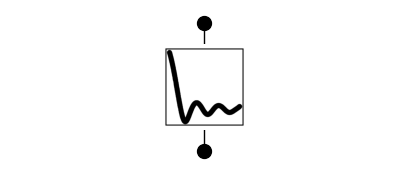

In [6]:
# Visualize learned activation functions on the QKAN edges
qkan.plot(from_acts=True, metric=None)

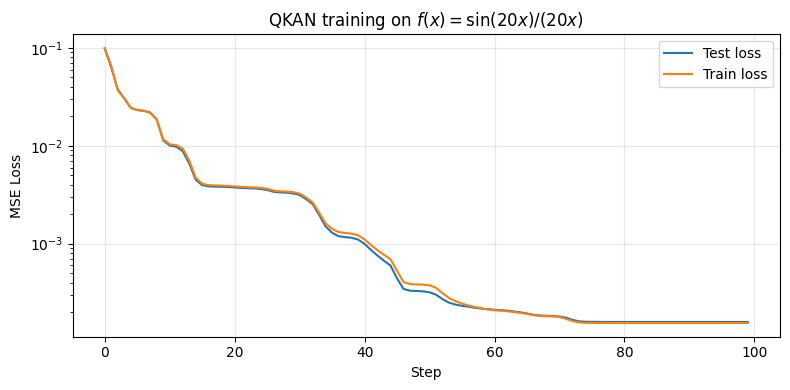

In [7]:
# Plot the training curve
plt.figure(figsize=(8, 4))
plt.plot(result["test_loss"], label="Test loss")
plt.plot(result["train_loss"], label="Train loss")
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.yscale("log")
plt.title("QKAN training on $f(x) = \\sin(20x)/(20x)$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1.6 Layer extension: progressive refinement

One of QKAN's practical training tools is **layer extension**: progressively increasing the number of repetitions $r$ in the DARUAN circuit during training. This is analogous to KAN's grid extension for B-splines and matters for scaling because deeper circuits are harder to optimize from scratch.

**How it works:**
1. Train a QKAN with a small $r$ (fast convergence)
2. Create a new QKAN with larger $r$ and **initialize from the previous model** via `initialize_from_another_model()`
3. New layers start as identity (parameters = 0), preserving learned features
4. Fine-tune so the added layers gradually adjust for higher accuracy

This avoids the vanishing-gradient issues of training deep circuits from scratch.

We'll fit $f(x, y) = \exp(\sin(\pi x) + y^2)$ with a `[2, 5, 1]` architecture. The demo uses a shortened repetition schedule and fewer optimizer steps so the audience sees the mechanism without waiting for the full experiment.

In [8]:
# f(x, y) = exp(sin(pi*x) + y^2)
f2 = lambda x: torch.exp(torch.sin(torch.pi * x[:, [0]]) + x[:, [1]] ** 2)
dataset2 = create_dataset(
    f2,
    n_var=2,
    device=device,
    train_num=LAYER_TRAIN_NUM,
    test_num=LAYER_TEST_NUM,
    seed=0,
)

# Step 1: Start with r=1 (shallow circuit)
model_ext = QKAN(
    [2, 5, 1],
    reps=1,
    device=device,
    preact_trainable=True,
    postact_bias_trainable=True,
    postact_weight_trainable=True,
    ba_trainable=True,
)
optimizer = torch.optim.Adam(model_ext.parameters(), lr=5e-3)

test_results_ext = []
qkans = [model_ext]

result = model_ext.train_(dataset2, optimizer=optimizer, steps=LAYER_INITIAL_STEPS, verbose=False)
test_results_ext += result["test_loss"]
print(f"Initial r=1 steps: {LAYER_INITIAL_STEPS}")


100%|█████████████████| 100/100 [00:00<00:00, 196.39it/s, train loss=0.93402475, test loss=1.018785]

Initial r=1 steps: 100


In [9]:
# Step 2: Progressively extend layers: r = 5, 10, 15, 20
reps_schedule = LAYER_EXT_REPS

for idx, r in enumerate(reps_schedule):
    qkans.append(
        QKAN(
            [2, 5, 1],
            reps=r,
            device=device,
            preact_trainable=True,
            postact_bias_trainable=True,
            postact_weight_trainable=True,
            ba_trainable=True,
        )
    )
    # Initialize new model from the previous (smaller) model
    qkans[-1].initialize_from_another_model(qkans[idx])

    optimizer = torch.optim.LBFGS(qkans[-1].parameters(), lr=5e-1)
    result = qkans[-1].train_(dataset2, optimizer=optimizer, steps=LAYER_EXT_STEPS, verbose=False)
    test_results_ext += result["test_loss"]
    print(f"Extended to r={r:2d} | final test loss: {result['test_loss'][-1]:.6e}")

print(f"Final test loss after layer extension: {test_results_ext[-1]:.6e}")


100%|██████████████| 100/100 [00:09<00:00, 10.27it/s, train loss=1.0701382e-06, test loss=9.885e-07]


Extended to r= 5 | final test loss: 9.885000e-07


100%|████████████| 100/100 [00:04<00:00, 21.21it/s, train loss=2.613945e-07, test loss=3.164231e-07]


Extended to r=10 | final test loss: 3.164231e-07


100%|██████████| 100/100 [00:04<00:00, 22.77it/s, train loss=1.10503976e-07, test loss=1.501832e-07]


Extended to r=15 | final test loss: 1.501832e-07


100%|███████████| 100/100 [00:04<00:00, 24.62it/s, train loss=7.345688e-08, test loss=9.4566964e-08]

Extended to r=20 | final test loss: 9.456696e-08
Final test loss after layer extension: 9.456696e-08


#### Compare with direct training at the final repetition count

For comparison, train a QKAN directly from scratch at the final repetition count. This run is deliberately shortened; it shows the contrast without turning the talk into a benchmark run.

In [10]:
# Direct training from scratch at the final repetition count
layer_direct_reps = LAYER_EXT_REPS[-1]
model_direct = QKAN(
    [2, 5, 1],
    reps=layer_direct_reps,
    device=device,
    preact_trainable=True,
    postact_bias_trainable=True,
    postact_weight_trainable=True,
    ba_trainable=True,
)
optimizer = torch.optim.LBFGS(model_direct.parameters(), lr=5e-1)
result_direct = model_direct.train_(dataset2, optimizer=optimizer, steps=LAYER_DIRECT_STEPS, verbose=False)
print(f"Direct r={layer_direct_reps} steps: {LAYER_DIRECT_STEPS}")

100%|██████████| 500/500 [00:40<00:00, 12.31it/s, train loss=4.0251788e-07, test loss=2.7714092e-05]

Direct r=20 steps: 500


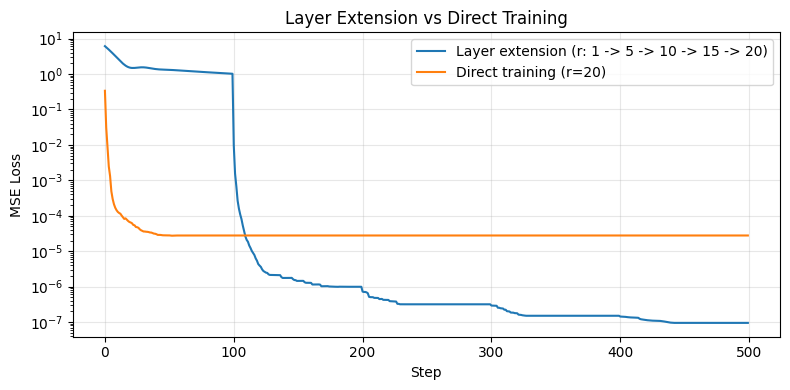

In [11]:
# Compare: layer extension vs direct training
plt.figure(figsize=(8, 4))
ext_label = "Layer extension (r: 1 -> " + " -> ".join(map(str, reps_schedule)) + ")"
plt.plot(test_results_ext, label=ext_label)
plt.plot(result_direct["test_loss"], label=f"Direct training (r={layer_direct_reps})")
plt.ylabel("MSE Loss")
plt.xlabel("Step")
plt.yscale("log")
plt.title("Layer Extension vs Direct Training")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

With the full training schedule, layer extension is expected to reach better loss in fewer effective optimization steps than direct high-depth training from scratch. The important mechanism is `initialize_from_another_model()`: it preserves learned structure while increasing circuit depth.


---
## Part 2: Scaling to LLMs with NVIDIA

### 2.1 Hybrid QKAN on MNIST as a runnable proxy

The afternoon QKAN topic is parameter-efficient architectures for LLMs. Before jumping into a transformer block, this MNIST example shows the same scaling pattern in a short supervised workload.

KAN-family layers have a **quadratic scaling** problem: a layer with $n_{in}$ inputs and $n_{out}$ outputs creates $n_{in} \times n_{out}$ learnable activation functions. **Hybrid QKAN (HQKAN)** addresses this by sandwiching a compact QKAN core between linear compression/expansion layers:

```
Features (d) -> Linear (d -> k) -> QKAN [k, k] -> Linear (k -> classes)
```

where $k \ll d$. This sharply reduces the number of variational activation functions while retaining QKAN's expressivity.

We'll demonstrate this on MNIST with a CNN that outputs 256-dimensional features, then compare the HQKAN head ($k=16$) against a standard MLP head.

In [12]:
import math
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader


class CNet(nn.Module):
    """CNN feature extractor that outputs 256-dim features."""

    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=5),   # 28->24
            nn.ReLU(),
            nn.MaxPool2d(2),                   # 24->12
            nn.Conv2d(8, 16, kernel_size=5),  # 12->8
            nn.ReLU(),
            nn.MaxPool2d(2),                   # 8->4
        )
        # Output: 16 * 4 * 4 = 256

    def forward(self, x):
        x = self.features(x)
        return x.flatten(start_dim=1)  # -> (batch, 256)


In [13]:
# Load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

trainset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=MNIST_BATCH_SIZE, shuffle=True)
testloader = DataLoader(testset, batch_size=MNIST_BATCH_SIZE, shuffle=False)

print(f"MNIST train samples: {len(trainset):,}; test samples: {len(testset):,}; epochs: {MNIST_EPOCHS}")


MNIST train samples: 60,000; test samples: 10,000; epochs: 20


#### 2.1.1 Train CNN + HQKAN

The HQKAN head compresses 256 CNN features down to $k=16$, applies a QKAN core `[k, k]`, then projects to 10 classes:

```
CNet (256) -> Linear(256, 16) -> QKAN([16, 16]) -> Linear(16, 10)
```

This is the same compression pattern used to replace wider feed-forward blocks at larger scale.


In [14]:
# CNN + HQKAN model
in_feat = 256  # CNet output dimension
k = HQKAN_COMPRESSED_DIM

hqkan_model = nn.Sequential(
    CNet(),
    nn.Linear(in_feat, k),         # compress: 256 -> k
    QKAN([k, k], device=device),   # QKAN core: [k, k]
    nn.Linear(k, 10),              # expand to classes: k -> 10
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(hqkan_model.parameters(), lr=1e-3)

hqkan_test_accs = []
hqkan_test_top3 = []

for epoch in range(MNIST_EPOCHS):
    hqkan_model.train()
    with tqdm(trainloader, desc=f"HQKAN Epoch {epoch+1:2d}/{MNIST_EPOCHS}", leave=False) as pbar:
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            output = hqkan_model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            acc = (output.argmax(dim=1) == labels).float().mean()
            pbar.set_postfix(loss=f"{loss.item():.3f}", acc=f"{acc.item():.3f}")

    hqkan_model.eval()
    test_acc = test_top3 = 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            output = hqkan_model(images)
            test_acc += (output.argmax(1) == labels).float().mean().item()
            test_top3 += (output.topk(3, 1).indices == labels.unsqueeze(1)).any(1).float().mean().item()
    test_acc /= len(testloader)
    test_top3 /= len(testloader)
    hqkan_test_accs.append(test_acc)
    hqkan_test_top3.append(test_top3)

    print(f"  Epoch {epoch+1:2d} | Test Acc: {test_acc:.4f} | Top-3: {test_top3:.4f}")

hqkan_params = sum(p.numel() for p in hqkan_model.parameters() if p.requires_grad)
hqkan_head_params = hqkan_params - sum(p.numel() for p in CNet().parameters())
print(f"\nCNN+HQKAN: Best Top-1 = {max(hqkan_test_accs):.4f}, Best Top-3 = {max(hqkan_test_top3):.4f}")
print(f"  Total params: {hqkan_params}, Head params: {hqkan_head_params}")

  Epoch  1 | Test Acc: 0.6909 | Top-3: 0.9351


  Epoch  2 | Test Acc: 0.9110 | Top-3: 0.9787


  Epoch  3 | Test Acc: 0.9478 | Top-3: 0.9912


  Epoch  4 | Test Acc: 0.9616 | Top-3: 0.9939


  Epoch  5 | Test Acc: 0.9690 | Top-3: 0.9957


...

  Epoch 16 | Test Acc: 0.9862 | Top-3: 0.9987


  Epoch 17 | Test Acc: 0.9869 | Top-3: 0.9989


  Epoch 18 | Test Acc: 0.9871 | Top-3: 0.9991


  Epoch 19 | Test Acc: 0.9877 | Top-3: 0.9994


  Epoch 20 | Test Acc: 0.9884 | Top-3: 0.9991

CNN+HQKAN: Best Top-1 = 0.9884, Best Top-3 = 0.9994
  Total params: 9754, Head params: 6330


#### 2.1.2 Train CNN + MLP baseline

Use the same CNN backbone with an MLP head: `256 -> 128 -> 10`. The baseline uses the same number of epochs and the same MNIST train/test split as HQKAN.


In [15]:
# CNN + MLP model
mlp_model = nn.Sequential(
    CNet(),
    nn.Linear(in_feat, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=1e-3)

mlp_test_accs = []
mlp_test_top3 = []

for epoch in range(MNIST_EPOCHS):
    mlp_model.train()
    with tqdm(trainloader, desc=f"MLP  Epoch {epoch+1:2d}/{MNIST_EPOCHS}", leave=False) as pbar:
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            output = mlp_model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            acc = (output.argmax(dim=1) == labels).float().mean()
            pbar.set_postfix(loss=f"{loss.item():.3f}", acc=f"{acc.item():.3f}")

    mlp_model.eval()
    test_acc = test_top3 = 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            output = mlp_model(images)
            test_acc += (output.argmax(1) == labels).float().mean().item()
            test_top3 += (output.topk(3, 1).indices == labels.unsqueeze(1)).any(1).float().mean().item()
    test_acc /= len(testloader)
    test_top3 /= len(testloader)
    mlp_test_accs.append(test_acc)
    mlp_test_top3.append(test_top3)

    print(f"  Epoch {epoch+1:2d} | Test Acc: {test_acc:.4f} | Top-3: {test_top3:.4f}")

mlp_params = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
mlp_head_params = mlp_params - sum(p.numel() for p in CNet().parameters())
print(f"\nCNN+MLP:  Best Top-1 = {max(mlp_test_accs):.4f}, Best Top-3 = {max(mlp_test_top3):.4f}")
print(f"  Total params: {mlp_params}, Head params: {mlp_head_params}")

  Epoch  1 | Test Acc: 0.9156 | Top-3: 0.9864


  Epoch  2 | Test Acc: 0.9560 | Top-3: 0.9952


  Epoch  3 | Test Acc: 0.9688 | Top-3: 0.9968


  Epoch  4 | Test Acc: 0.9759 | Top-3: 0.9983


  Epoch  5 | Test Acc: 0.9791 | Top-3: 0.9985


...

  Epoch 16 | Test Acc: 0.9890 | Top-3: 0.9994


  Epoch 17 | Test Acc: 0.9888 | Top-3: 0.9995


  Epoch 18 | Test Acc: 0.9881 | Top-3: 0.9994


  Epoch 19 | Test Acc: 0.9900 | Top-3: 0.9998


  Epoch 20 | Test Acc: 0.9906 | Top-3: 0.9997

CNN+MLP:  Best Top-1 = 0.9906, Best Top-3 = 0.9998
  Total params: 37610, Head params: 34186


#### 2.1.3 Compare accuracy and head parameters

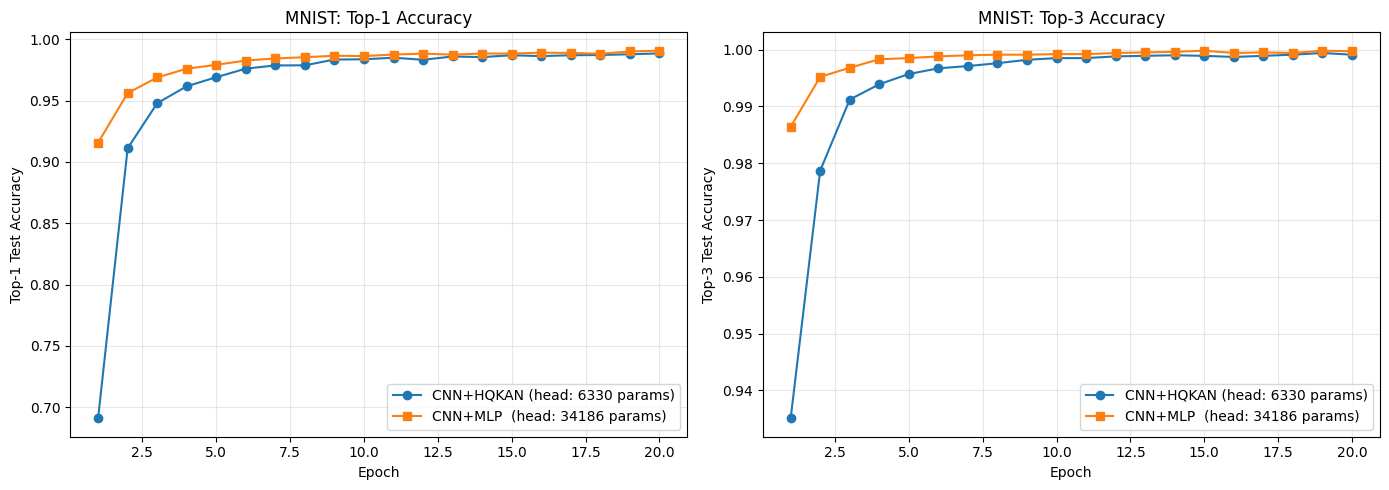


Model             Top-1    Top-3  Head Params  Total Params
------------------------------------------------------------
CNN+HQKAN        0.9884   0.9994        6,330         9,754
CNN+MLP          0.9906   0.9998       34,186        37,610

Head parameter reduction: 5.4x


In [16]:
# Plot accuracy comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, MNIST_EPOCHS + 1)

ax1.plot(epochs, hqkan_test_accs, "o-", label=f"CNN+HQKAN (head: {hqkan_head_params} params)", color="tab:blue")
ax1.plot(epochs, mlp_test_accs, "s-", label=f"CNN+MLP  (head: {mlp_head_params} params)", color="tab:orange")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Top-1 Test Accuracy")
ax1.set_title("MNIST: Top-1 Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, hqkan_test_top3, "o-", label=f"CNN+HQKAN (head: {hqkan_head_params} params)", color="tab:blue")
ax2.plot(epochs, mlp_test_top3, "s-", label=f"CNN+MLP  (head: {mlp_head_params} params)", color="tab:orange")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Top-3 Test Accuracy")
ax2.set_title("MNIST: Top-3 Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Model':<14} {'Top-1':>8} {'Top-3':>8} {'Head Params':>12} {'Total Params':>13}")
print("-" * 60)
print(f"{'CNN+HQKAN':<14} {max(hqkan_test_accs):>8.4f} {max(hqkan_test_top3):>8.4f} {hqkan_head_params:>12,} {hqkan_params:>13,}")
print(f"{'CNN+MLP':<14} {max(mlp_test_accs):>8.4f} {max(mlp_test_top3):>8.4f} {mlp_head_params:>12,} {mlp_params:>13,}")
print(f"\nHead parameter reduction: {mlp_head_params/hqkan_head_params:.1f}x")


The HQKAN head keeps the QKAN core compact through linear compression (`256 -> k`) while retaining the same architecture pattern used to replace transformer feed-forward MLPs. The comparison reports both accuracy and head parameter count so the compression trade-off is visible.


### 2.2 The pattern scales: HQKAN in transformer feed-forward blocks

The HQKAN pattern from the MNIST proxy (Linear compress -> QKAN core -> Linear expand) scales directly to large models. In a **GPT-2 transformer**, each block's MLP can be replaced with an HQKAN module:

**Standard GPT-2 MLP:**
```
Linear(768 -> 3072) -> GELU -> Linear(3072 -> 768)    # ~4.7M params per block
```

**HQKAN replacement:**
```
Linear(768 -> 10) -> QKAN([10, 10]) -> Linear(10 -> 768)    # ~16K params per block
```

where $k = \lceil \log_2(768) \rceil = 10$. Let's build both blocks and compare their parameter counts and tensor shapes. The live `cutn` section below scales this into a full 12-layer GPT-2-style model benchmark.


In [17]:
import math


class HQKANBlock(nn.Module):
    """
    A transformer block that replaces the standard MLP with Hybrid QKAN.
    Adapted from karpathy/nanoGPT with HQKAN modules.
    """

    def __init__(self, n_embd, n_head, dropout=0.0, bias=True, qkan_solver="cutn", qkan_c_dtype=torch.complex64):
        super().__init__()
        self.ln_1 = nn.LayerNorm(n_embd)
        # Standard causal self-attention
        self.c_attn = nn.Linear(n_embd, 3 * n_embd, bias=bias)
        self.c_proj = nn.Linear(n_embd, n_embd, bias=bias)
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)
        self.n_head = n_head
        self.n_embd = n_embd
        self.qkan_solver = qkan_solver
        self.qkan_c_dtype = qkan_c_dtype

        # HQKAN replaces the MLP
        self.ln_2 = nn.LayerNorm(n_embd)
        k = math.ceil(math.log2(n_embd))  # compressed dimension
        self.hqkan = nn.Sequential(
            nn.Linear(n_embd, k),                   # compress: 768 -> 10
            QKAN(
                width=[k, k],                        # compact QKAN core
                reps=1,
                device=device,
                ansatz="real",
                solver=qkan_solver,
                c_dtype=qkan_c_dtype,
                ba_trainable=True,
            ),
            nn.Linear(k, n_embd),                   # expand: 10 -> 768
            nn.Dropout(dropout),
        )

    def forward(self, x):
        B, T, C = x.size()
        # Self-attention
        qkv = self.c_attn(self.ln_1(x))
        q, k, v = qkv.split(self.n_embd, dim=2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        x = x + self.resid_dropout(self.c_proj(y))
        # HQKAN feed-forward (replaces MLP)
        x = x + self.hqkan(self.ln_2(x))
        return x


# Standard MLP block for comparison
class MLPBlock(nn.Module):
    """Standard GPT-2 transformer block with MLP."""

    def __init__(self, n_embd, n_head, dropout=0.0, bias=True):
        super().__init__()
        self.ln_1 = nn.LayerNorm(n_embd)
        self.c_attn = nn.Linear(n_embd, 3 * n_embd, bias=bias)
        self.c_proj = nn.Linear(n_embd, n_embd, bias=bias)
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)
        self.n_head = n_head
        self.n_embd = n_embd

        self.ln_2 = nn.LayerNorm(n_embd)
        self.mlp = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd, bias=bias),  # GPT-2 standard: 4x expansion
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd, bias=bias),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        B, T, C = x.size()
        qkv = self.c_attn(self.ln_1(x))
        q, k, v = qkv.split(self.n_embd, dim=2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        x = x + self.resid_dropout(self.c_proj(y))
        x = x + self.mlp(self.ln_2(x))
        return x



class GPT2Stack(nn.Module):
    """GPT-2-style language model stack with selectable feed-forward block."""

    def __init__(
        self,
        block_type,
        n_layer=12,
        n_embd=768,
        n_head=12,
        vocab_size=50_257,
        block_size=1024,
        dropout=0.0,
        bias=True,
        qkan_solver="cutn",
        qkan_c_dtype=torch.complex64,
    ):
        super().__init__()
        if block_type not in {"hqkan", "mlp"}:
            raise ValueError("block_type must be 'hqkan' or 'mlp'")

        self.block_type = block_type
        self.n_layer = n_layer
        self.n_embd = n_embd
        self.n_head = n_head
        self.vocab_size = vocab_size
        self.block_size = block_size

        self.wte = nn.Embedding(vocab_size, n_embd)
        self.wpe = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)
        self.h = nn.ModuleList(
            [
                HQKANBlock(
                    n_embd,
                    n_head,
                    dropout=dropout,
                    bias=bias,
                    qkan_solver=qkan_solver,
                    qkan_c_dtype=qkan_c_dtype,
                )
                if block_type == "hqkan"
                else MLPBlock(n_embd, n_head, dropout=dropout, bias=bias)
                for _ in range(n_layer)
            ]
        )
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)
        self.lm_head.weight = self.wte.weight  # GPT-2 weight tying

    def forward(self, idx):
        batch_size, seq_len = idx.shape
        if seq_len > self.block_size:
            raise ValueError(f"sequence length {seq_len} exceeds block_size {self.block_size}")

        pos = torch.arange(0, seq_len, dtype=torch.long, device=idx.device)
        x = self.wte(idx) + self.wpe(pos)[None, :, :]
        x = self.drop(x)
        for block in self.h:
            x = block(x)
        x = self.ln_f(x)
        return self.lm_head(x)


#### 2.2.1 Parameter comparison: HQKAN vs MLP transformer block

Let's compare a single transformer block at GPT-2 scale (`n_embd=768`, `n_head=12`).

In [18]:
# Build one block of each type at GPT-2 scale
n_embd, n_head = 768, 12
GPT2_N_LAYER = 12
GPT2_VOCAB_SIZE = 50_257
GPT2_BLOCK_SIZE = 1024

hqkan_block = HQKANBlock(
    n_embd,
    n_head,
    qkan_solver="cutn",
    qkan_c_dtype=torch.complex64,
).to(device)
mlp_block = MLPBlock(n_embd, n_head).to(device)

# Count parameters
def count_params(module, label=""):
    total = sum(p.numel() for p in module.parameters())
    trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
    return total, trainable

hqkan_total, hqkan_train = count_params(hqkan_block)
mlp_total, mlp_train = count_params(mlp_block)

# Separate attention vs feed-forward params
def count_ff_params(block, ff_attr):
    ff = getattr(block, ff_attr)
    return sum(p.numel() for p in ff.parameters())

hqkan_ff = count_ff_params(hqkan_block, "hqkan")
mlp_ff = count_ff_params(mlp_block, "mlp")

embedding_params = GPT2_VOCAB_SIZE * n_embd + GPT2_BLOCK_SIZE * n_embd
final_ln_params = 2 * n_embd
hqkan_gpt2_est = embedding_params + GPT2_N_LAYER * hqkan_total + final_ln_params
mlp_gpt2_est = embedding_params + GPT2_N_LAYER * mlp_total + final_ln_params

print("HQKAN core solver: cutn (c_dtype=complex64)")
print(f"{'Component':<25} {'HQKAN Block':>15} {'MLP Block':>15} {'Reduction':>10}")
print("-" * 68)
print(f"{'Feed-forward params':<25} {hqkan_ff:>15,} {mlp_ff:>15,} {mlp_ff/hqkan_ff:>9.1f}x")
print(f"{'Total block params':<25} {hqkan_total:>15,} {mlp_total:>15,} {mlp_total/hqkan_total:>9.1f}x")
print(f"\nFull 12-layer GPT-2-style model estimate with tied LM head:")
print(f"  HQKAN GPT-2: ~{hqkan_gpt2_est / 1e6:.1f}M params")
print(f"  MLP GPT-2:   ~{mlp_gpt2_est / 1e6:.1f}M params (standard GPT-2: 124M)")


HQKAN core solver: cutn (c_dtype=complex64)
Component                     HQKAN Block       MLP Block  Reduction
--------------------------------------------------------------------
Feed-forward params                16,838       4,722,432     280.5x
Total block params              2,382,278       7,087,872       3.0x

Full 12-layer GPT-2-style model estimate with tied LM head:
  HQKAN GPT-2: ~68.0M params
  MLP GPT-2:   ~124.4M params (standard GPT-2: 124M)


In [19]:
# Verify the blocks produce correct output shapes
x = torch.randn(2, 16, n_embd, device=device)  # (batch=2, seq_len=16, n_embd=768)

with torch.no_grad():
    out_hqkan = hqkan_block(x)
    out_mlp = mlp_block(x)

print(f"Input shape:        {list(x.shape)}")
print(f"HQKAN output shape: {list(out_hqkan.shape)}")
print(f"MLP output shape:   {list(out_mlp.shape)}")
print("\nBoth blocks are drop-in compatible -- same input/output dimensions.")

Input shape:        [2, 16, 768]
HQKAN output shape: [2, 16, 768]
MLP output shape:   [2, 16, 768]

Both blocks are drop-in compatible -- same input/output dimensions.


### 2.3 `cutn` / cuTensorNet solver demo

HQKAN at LLM scale still uses ordinary PyTorch modules for embeddings, attention, layer norms, and the LM head. The QKAN feed-forward core is the part we switch here: every DARUAN activation is evaluated with `solver="cutn"` instead of the CuTe fused-kernel path.

| Solver | Backend | Purpose in this notebook |
|:---|:---|:---|
| **`cutn`** | **Tensor-network contraction, with cuQuantum/cuTensorNet path planning when available** | **Run full GPT-2-style HQKAN training through the tensor-network QKAN backend** |

Conceptually, each QKAN edge is a one-qubit circuit. The `cutn` backend converts that circuit into an einsum-style tensor network, asks cuTensorNet for a contraction path when the `cuquantum` package is installed, caches that plan by tensor shape, and then reuses it during repeated calls. This keeps the model interface unchanged: only the `QKAN(..., solver="cutn")` argument changes. The first pass can include contraction-path setup and cache population, so the steady-state timing after warmup is the throughput number to use for comparison.

The live cell below benchmarks a full 12-layer GPT-2-style language model: token embeddings, positional embeddings, all transformer blocks, final layer norm, and tied LM head. The HQKAN model uses `solver="cutn"` in every QKAN feed-forward replacement and uses `c_dtype=torch.complex64`, because the tensor-network path carries complex quantum amplitudes. The benchmark runs both models in training mode and reports steady-state forward+backward time using a synthetic scalar loss over logits.


#### 2.3.1 Steady-state full GPT-2 training throughput

Run this cell during the demo. It times a complete 12-layer GPT-2-style HQKAN language model with `solver="cutn"` against the standard MLP GPT-2 baseline on the same token input. Each timed iteration runs `model.train()`, a forward pass, a synthetic scalar loss, backward propagation, and gradient clearing; optimizer updates are intentionally omitted so the comparison isolates model forward+backward cost.


In [26]:
import time

# Live benchmark: full 12-layer GPT-2-style model training throughput.
GPT2_BENCH_N_LAYER = 12
GPT2_BENCH_VOCAB_SIZE = 50_257
GPT2_BENCH_BLOCK_SIZE = 1024
GPT2_BENCH_BATCH = 8
GPT2_BENCH_SEQ_LEN = 1024
GPT2_TRAIN_WARMUP_ITERS = 5
GPT2_TRAIN_TIMED_ITERS = 3
QKAN_BENCH_SOLVER = "cutn"
QKAN_BENCH_C_DTYPE = torch.complex64


def sync_if_cuda():
    if device.type == "cuda":
        torch.cuda.synchronize()


def tokens_per_second(idx, ms_per_iter):
    return idx.numel() / (ms_per_iter / 1000)


def benchmark_training_step(model, idx, warmup=GPT2_TRAIN_WARMUP_ITERS, iters=GPT2_TRAIN_TIMED_ITERS):
    model.train()
    model.zero_grad(set_to_none=True)

    for _ in range(warmup):
        logits = model(idx)
        loss = logits.float().square().mean()
        loss.backward()
        model.zero_grad(set_to_none=True)
    sync_if_cuda()

    t0 = time.perf_counter()
    for _ in range(iters):
        logits = model(idx)
        loss = logits.float().square().mean()
        loss.backward()
        model.zero_grad(set_to_none=True)
    sync_if_cuda()

    return (time.perf_counter() - t0) / iters * 1000


gpt2_idx = torch.randint(
    0,
    GPT2_BENCH_VOCAB_SIZE,
    (GPT2_BENCH_BATCH, GPT2_BENCH_SEQ_LEN),
    device=device,
)

hqkan_gpt2 = GPT2Stack(
    "hqkan",
    n_layer=GPT2_BENCH_N_LAYER,
    n_embd=n_embd,
    n_head=n_head,
    vocab_size=GPT2_BENCH_VOCAB_SIZE,
    block_size=GPT2_BENCH_BLOCK_SIZE,
    qkan_solver=QKAN_BENCH_SOLVER,
    qkan_c_dtype=QKAN_BENCH_C_DTYPE,
).to(device)

mlp_gpt2 = GPT2Stack(
    "mlp",
    n_layer=GPT2_BENCH_N_LAYER,
    n_embd=n_embd,
    n_head=n_head,
    vocab_size=GPT2_BENCH_VOCAB_SIZE,
    block_size=GPT2_BENCH_BLOCK_SIZE,
).to(device)

full_gpt2_train_results = []
for label, model in [("HQKAN GPT-2", hqkan_gpt2), ("MLP GPT-2", mlp_gpt2)]:
    train_ms = benchmark_training_step(model, gpt2_idx)
    full_gpt2_train_results.append(
        {
            "model": label,
            "params": sum(p.numel() for p in model.parameters()),
            "train_ms": train_ms,
            "train_tps": tokens_per_second(gpt2_idx, train_ms),
        }
    )

mlp_train_tps = next(row["train_tps"] for row in full_gpt2_train_results if row["model"] == "MLP GPT-2")

print(
    f"Full GPT-2 training input: batch={GPT2_BENCH_BATCH}, seq_len={GPT2_BENCH_SEQ_LEN}, "
    f"layers={GPT2_BENCH_N_LAYER}, vocab={GPT2_BENCH_VOCAB_SIZE}, device={device}, "
    f"qkan_solver={QKAN_BENCH_SOLVER}, c_dtype={QKAN_BENCH_C_DTYPE}"
)
print(f"{'Model':<13} {'params':>9} {'train ms':>10} {'train tok/s':>13} {'vs MLP':>10}")
print("-" * 62)
for row in full_gpt2_train_results:
    rel_train = row["train_tps"] / mlp_train_tps
    print(
        f"{row['model']:<13} {row['params']/1e6:>8.1f}M {row['train_ms']:>10.3f} "
        f"{row['train_tps']:>13,.0f} {rel_train:>9.2f}x"
    )

del hqkan_gpt2, mlp_gpt2
if device.type == "cuda":
    torch.cuda.empty_cache()


Full GPT-2 training input: batch=8, seq_len=1024, layers=12, vocab=50257, device=cuda, qkan_solver=cutn, c_dtype=torch.complex64
Model            params   train ms   train tok/s     vs MLP
--------------------------------------------------------------
HQKAN GPT-2       68.0M    100.886        81,200      1.42x
MLP GPT-2        124.4M    143.403        57,126      1.00x


---
## Part 3: Transfer and Takeaways

### 3.1 Landscape demo: QKAN to KAN knowledge transfer

The main throughline of this notebook is QKAN as a parameter-efficient, GPU-accelerated architecture. This final experiment connects the runnable notebook to the paper's optimization-landscape result. QKAN can exhibit a **better optimization landscape** than classical KAN, demonstrated through knowledge transfer:

1. Train a QKAN on a target function
2. Transfer the learned weights to a classical KAN via `initialize_from_qkan()`
3. Fine-tune the KAN
4. Compare against a KAN trained from scratch

If the transferred KAN converges to a better solution, it suggests QKAN navigated the loss landscape more effectively.

We'll fit $f(x, y) = \sin(e^x + y^2)$.


In [21]:
# Create dataset for transfer experiment
f_transfer = lambda x: torch.sin(torch.exp(x[:, [0]]) + x[:, [1]] ** 2)
dataset_transfer = create_dataset(
    f_transfer,
    n_var=2,
    train_num=TRANSFER_TRAIN_NUM,
    test_num=TRANSFER_TEST_NUM,
    device=device,
    seed=0,
)

# Step 1: Train QKAN
qkan_transfer = QKAN(
    [2, 1, 1],
    num_qlayers=3,
    solver="exact",
    device=device,
    preact_trainable=True,
    postact_bias_trainable=False,
    postact_weight_trainable=False,
    ba_trainable=True,
    seed=0,
)
optimizer = optim.Adam(qkan_transfer.parameters(), lr=1e-2)
result_qkan = qkan_transfer.train_(dataset_transfer, steps=TRANSFER_QKAN_STEPS, optimizer=optimizer, verbose=False)


100%|███████████| 500/500 [00:04<00:00, 115.64it/s, train loss=0.0025606842, test loss=0.0022567941]


In [22]:
# Step 2: Transfer QKAN -> KAN and fine-tune
kan_transferred = KAN([2, 1, 1], grid_size=5, seed=0).to(device)

# Sample points for spline initialization from QKAN activations
x0 = torch.stack(
    [torch.linspace(-1, 1, steps=100, device=device) for _ in range(2)]
).permute(1, 0)
kan_transferred.initialize_from_qkan(qkan_transfer, x0=x0, sampling=100)

# Fine-tune the transferred KAN
optimizer = optim.Adam(kan_transferred.parameters(), lr=1e-2)
criterion = nn.MSELoss()

batch_size = dataset_transfer["train_input"].shape[0]
batch_size_test = dataset_transfer["test_input"].shape[0]
transfer_batch = TRANSFER_BATCH_SIZE or batch_size
transfer_test_batch = min(transfer_batch, batch_size_test)

for step in tqdm(range(TRANSFER_TRANSFER_STEPS), desc="KAN (from QKAN)", ncols=100):
    train_id = np.random.choice(batch_size, min(transfer_batch, batch_size), replace=False)
    test_id = np.random.choice(batch_size_test, transfer_test_batch, replace=False)

    pred = kan_transferred(dataset_transfer["train_input"][train_id].to(device))
    loss = criterion(pred, dataset_transfer["train_label"][train_id].to(device))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    test_loss = criterion(
        kan_transferred(dataset_transfer["test_input"][test_id].to(device)),
        dataset_transfer["test_label"][test_id].to(device),
    )
    result_qkan["train_loss"].append(loss.cpu().detach().numpy())
    result_qkan["test_loss"].append(test_loss.cpu().detach().numpy())


KAN (from QKAN): 100%|█████████████████████████████████████████| 1000/1000 [00:01<00:00, 601.43it/s]


In [23]:
# Step 3: Train a KAN from scratch for comparison
kan_scratch = KAN([2, 1, 1], grid_size=5, seed=0).to(device)

optimizer = optim.Adam(kan_scratch.parameters(), lr=1e-2)
result_kan = {"train_loss": [], "test_loss": []}

batch_size = dataset_transfer["train_input"].shape[0]
batch_size_test = dataset_transfer["test_input"].shape[0]
transfer_batch = TRANSFER_BATCH_SIZE or batch_size
transfer_test_batch = min(transfer_batch, batch_size_test)

for step in tqdm(range(TRANSFER_SCRATCH_STEPS), desc="KAN (scratch)", ncols=100):
    train_id = np.random.choice(batch_size, min(transfer_batch, batch_size), replace=False)
    test_id = np.random.choice(batch_size_test, transfer_test_batch, replace=False)

    pred = kan_scratch(dataset_transfer["train_input"][train_id].to(device))
    loss = criterion(pred, dataset_transfer["train_label"][train_id].to(device))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    test_loss = criterion(
        kan_scratch(dataset_transfer["test_input"][test_id].to(device)),
        dataset_transfer["test_label"][test_id].to(device),
    )
    result_kan["train_loss"].append(loss.cpu().detach().numpy())
    result_kan["test_loss"].append(test_loss.cpu().detach().numpy())


KAN (scratch): 100%|███████████████████████████████████████████| 1500/1500 [00:02<00:00, 619.16it/s]


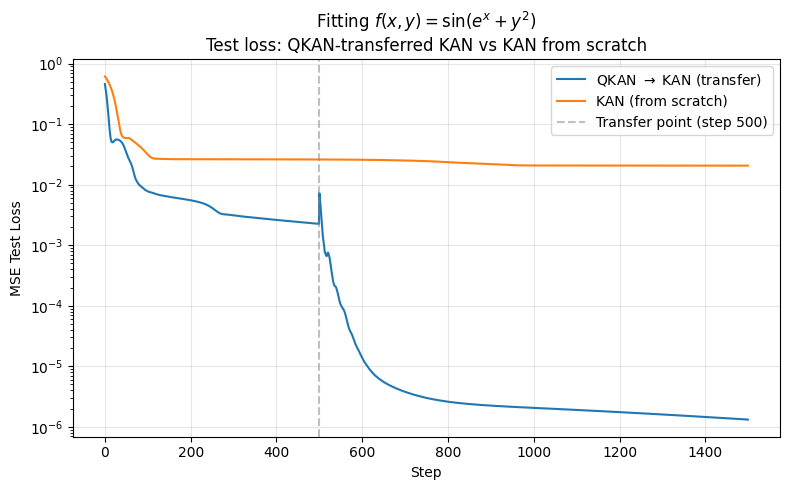

In [24]:
# Plot comparison
plt.figure(figsize=(8, 5))
plt.plot(result_qkan["test_loss"], label=r"QKAN $\rightarrow$ KAN (transfer)")
plt.plot(result_kan["test_loss"], label="KAN (from scratch)")
plt.xlabel("Step")
plt.ylabel("MSE Test Loss")
plt.yscale("log")
plt.title(r"Fitting $f(x,y) = \sin(e^x + y^2)$" + "\nTest loss: QKAN-transferred KAN vs KAN from scratch")
plt.axvline(
    x=TRANSFER_QKAN_STEPS,
    color="gray",
    linestyle="--",
    alpha=0.5,
    label=f"Transfer point (step {TRANSFER_QKAN_STEPS})",
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The QKAN-transferred KAN can converge to substantially lower loss than the KAN trained from scratch. This provides evidence that QVAFs can navigate a better optimization landscape than classical variational activation functions. In the paper, the authors report a **70% reduction in test loss** through this transfer approach.


---
## Summary

In this tutorial, we covered:

| Section | Key Takeaway |
|:---|:---|
| **Background** | QKAN replaces classical splines in KAN with single-qubit quantum circuits (DARUANs), achieving exponential parameter reduction via trainable frequency spectra |
| **Function fitting** | QKAN can fit complex functions with very few parameters using the `train_()` API and LBFGS optimization |
| **Layer extension** | Progressively increasing circuit depth avoids difficult direct optimization of high-depth circuits |
| **HQKAN classification** | Hybrid QKAN (Linear compress -> QKAN -> Linear expand) achieves the same architectural pattern used for larger parameter-efficient blocks |
| **Scaling to LLMs** | The same HQKAN pattern reduces feed-forward parameters while preserving GPT-2 block input/output compatibility |
| **`cutn` solver demo** | The live benchmark uses `solver="cutn"` to compare steady-state full 12-layer GPT-2 training throughput against the MLP baseline |
| **QKAN-to-KAN transfer** | QKAN's optimization landscape enables knowledge transfer to classical KAN, yielding lower loss in the reported experiment |

### Beyond this tutorial

The `qkan` library also supports:
- **Multiple ansatzes:** `pz_encoding`, `rpz_encoding`, `real` with different expressivity/speed trade-offs
- **GPU/tensor-network solvers:** `cutn` (cuQuantum/cuTensorNet path planning), `flash` (Triton), and `cute` (CuTe DSL / CUTLASS) for different execution trade-offs
- **Mixed precision:** BF16/FP8 paths for supported CuTe/CUDA package combinations
- **Pruning and visualization:** Interpretability tools for understanding learned functions
- **Real-hardware deployment:** `qiskit` and `cudaq` backends for execution on NISQ devices

### References
* Paper: [Quantum Variational Activation Functions Empower Kolmogorov-Arnold Networks](https://arxiv.org/abs/2509.14026) (Jiang et al., 2025)
* Documentation: [qkan.jimq.cc](https://qkan.jimq.cc/)
* GitHub: [github.com/Jim137/qkan](https://github.com/Jim137/qkan)
* CUDA-Q: [nvidia.github.io/cuda-quantum](https://nvidia.github.io/cuda-quantum/latest/index.html)
* cuQuantum SDK: [docs.nvidia.com/cuda/cuquantum](https://docs.nvidia.com/cuda/cuquantum/latest/index.html)
* CuTe DSL / CUTLASS: [docs.nvidia.com/cutlass/latest/media/docs/pythonDSL/cute_dsl.html](https://docs.nvidia.com/cutlass/latest/media/docs/pythonDSL/cute_dsl.html)


---
## Coming up next — Notebook 04

QKAN demonstrated the *quantum-inspired* family. The next notebook (`04_cutn-qsvm.ipynb`) closes the tutorial with the *quantum-enhanced* family: a classical SVM whose kernel is computed by a quantum circuit, scaled with cuQuantum batched contraction and (optionally) a multi-stream cuTENSOR C++ backend.